## Machine Learning Project
### Predicting Country Happiness Levels Using Socioeconomic Indicators

### 1. Business Understanding
#### Project Objective:
- Build a machine learning classification model capable of predicting a country's happiness level - low, medium or high - based on several socioeconomic indicators from the World Happiness Report.
- The project will compare several machine learning algorithms to determine which model provides better predictions while also identifying which variables contribute the most to the classification.

#### Machine Learning Problem:
- This project addresses a supervised multiclass classification problem.
- The target variable, happiness level, will be created by dividing countries into three categories based on their happiness scores:
- - Low Happiness
  - Medium Happiness
  - High Happiness
- The predictors will consist of socioeconomic indicaros such as:
- - GDP per capita
  - Social support
  - Healthy life expectancy
  - Freedom
  - Generosity
  - Perceptions of corruption

#### Hypothesis
- Countries with higher levels of economic prosperity, stronger social support systems, longer healthy life expectancy, greater personal freedom, and lower perceived corruption are more likely to belong to the High Happiness group, while countries with lower values for these indicators are more likely to be classified in the Low Happiness group.

### 2. Data Understanding

In [2]:
import pandas as pd
df2015 = pd.read_csv("../data/2015.csv")
df2016 = pd.read_csv("../data/2016.csv")
df2017 = pd.read_csv("../data/2017.csv")
df2018 = pd.read_csv("../data/2018.csv")
df2019 = pd.read_csv("../data/2019.csv")

In [3]:
df2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [4]:
df2019.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [5]:
print("2015")
print(df2015.columns.tolist())

print("\n2016")
print(df2016.columns.tolist())

print("\n2017")
print(df2017.columns.tolist())

print("\n2018")
print(df2018.columns.tolist())

print("\n2019")
print(df2019.columns.tolist())

2015
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2016
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2017
['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

2018
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

2019
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social supp

In [6]:
#renaming the columns for every dataset
df2015 = df2015.rename(columns={
    "Country": "Country",
    "Happiness Score": "Happiness_Score",
    "Economy (GDP per Capita)": "GDP",
    "Family": "Social_Support",
    "Health (Life Expectancy)": "Life_Expectancy",
    "Freedom": "Freedom",
    "Trust (Government Corruption)": "Corruption",
    "Generosity": "Generosity"
})

In [7]:
df2016 = df2016.rename(columns={
    "Country": "Country",
    "Happiness Score": "Happiness_Score",
    "Economy (GDP per Capita)": "GDP",
    "Family": "Social_Support",
    "Health (Life Expectancy)": "Life_Expectancy",
    "Freedom": "Freedom",
    "Trust (Government Corruption)": "Corruption",
    "Generosity": "Generosity"
})

In [8]:
df2017 = df2017.rename(columns={
    "Country": "Country",
    "Happiness.Score": "Happiness_Score",
    "Economy..GDP.per.Capita.": "GDP",
    "Family": "Social_Support",
    "Health..Life.Expectancy.": "Life_Expectancy",
    "Freedom": "Freedom",
    "Trust..Government.Corruption.": "Corruption",
    "Generosity": "Generosity"
})

In [9]:
df2018 = df2018.rename(columns={
    "Country or region": "Country",
    "Score": "Happiness_Score",
    "GDP per capita": "GDP",
    "Social support": "Social_Support",
    "Healthy life expectancy": "Life_Expectancy",
    "Freedom to make life choices": "Freedom",
    "Perceptions of corruption": "Corruption",
    "Generosity": "Generosity"
})

In [10]:
df2019 = df2019.rename(columns={
    "Country or region": "Country",
    "Score": "Happiness_Score",
    "GDP per capita": "GDP",
    "Social support": "Social_Support",
    "Healthy life expectancy": "Life_Expectancy",
    "Freedom to make life choices": "Freedom",
    "Perceptions of corruption": "Corruption",
    "Generosity": "Generosity"
})

In [11]:
#adding the year column
df2015["Year"] = 2015
df2016["Year"] = 2016
df2017["Year"] = 2017
df2018["Year"] = 2018
df2019["Year"] = 2019

In [12]:
#keeping only the matching variables
columns = [
    "Country",
    "Year",
    "Happiness_Score",
    "GDP",
    "Social_Support",
    "Life_Expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]

df2015 = df2015[columns]
df2016 = df2016[columns]
df2017 = df2017[columns]
df2018 = df2018[columns]
df2019 = df2019[columns]

In [13]:
#merging into one single dataset
df = pd.concat(
    [df2015, df2016, df2017, df2018, df2019],
    ignore_index=True)

In [14]:
df.head()

,Country,Year,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption
0,Switzerland,2015,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,Iceland,2015,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,Denmark,2015,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,Norway,2015,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,Canada,2015,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [15]:
df["Happiness_Score"].describe()

count    782.000000
mean       5.379018
std        1.127456
min        2.693000
25%        4.509750
50%        5.322000
75%        6.189500
max        7.769000
Name: Happiness_Score, dtype: float64

In [16]:
df.shape

(782, 9)

In [17]:
df.isnull().sum()

Country            0
Year               0
Happiness_Score    0
GDP                0
Social_Support     0
Life_Expectancy    0
Freedom            0
Generosity         0
Corruption         1
dtype: int64

In [18]:
df[df["Corruption"].isnull()]

,Country,Year,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption
489,United Arab Emirates,2018,6.774,2.096,0.776,0.67,0.284,0.186,NaN


In [19]:
df[df["Country"] == "United Arab Emirates"]

,Country,Year,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption
19,United Arab Emirates,2015,6.901,1.427270,1.12575,0.809250,0.641570,0.264280,0.38583
185,United Arab Emirates,2016,6.573,1.573520,0.87114,0.729930,0.562150,0.265910,0.35561
335,United Arab Emirates,2017,6.648,1.626343,1.26641,0.726798,0.608345,0.360942,0.32449
489,United Arab Emirates,2018,6.774,2.096000,0.77600,0.670000,0.284000,0.186000,NaN
646,United Arab Emirates,2019,6.825,1.503000,1.31000,0.825000,0.598000,0.262000,0.18200


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          782 non-null    object 
 1   Year             782 non-null    int64  
 2   Happiness_Score  782 non-null    float64
 3   GDP              782 non-null    float64
 4   Social_Support   782 non-null    float64
 5   Life_Expectancy  782 non-null    float64
 6   Freedom          782 non-null    float64
 7   Generosity       782 non-null    float64
 8   Corruption       781 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 55.1+ KB


### 3. Data Preparation

In [22]:
#creating the target variable
df["Happiness_Category"] = pd.cut(
    df["Happiness_Score"],
    bins=[0, 4, 6, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [23]:
df["Happiness_Category"].value_counts()

Happiness_Category
Medium    452
High      234
Low        96
Name: count, dtype: int64

In [24]:
df["Happiness_Category"].value_counts(normalize=True) * 100

Happiness_Category
Medium    57.800512
High      29.923274
Low       12.276215
Name: proportion, dtype: float64

In [26]:
#defining features and target
features = df.drop(columns=["Happiness_Score", "Happiness_Category"])
target = df["Happiness_Category"]

In [27]:
#train-test split
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (625, 8)
Testing set: (157, 8)


In [33]:
print(X_train.isnull().sum())

Country            0
Year               0
GDP                0
Social_Support     0
Life_Expectancy    0
Freedom            0
Generosity         0
Corruption         0
dtype: int64


In [34]:
print(X_test.isnull().sum())

Country            0
Year               0
GDP                0
Social_Support     0
Life_Expectancy    0
Freedom            0
Generosity         0
Corruption         0
dtype: int64


In [32]:
#removing the null value from test
mask = X_train.notna().all(axis=1)

X_train = X_train[mask]
y_train = y_train[mask]

In [35]:
print(X_train.shape)
print(X_test.shape)

(624, 8)
(157, 8)


### 4. EDA (Train Data)

In [36]:
train_df = X_train.copy()
train_df["Happiness_Category"] = y_train

In [37]:
train_df.head()

,Country,Year,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption,Happiness_Category
482,Costa Rica,2018,1.0100,1.45900,0.81700,0.63200,0.14300,0.10100,High
683,Japan,2019,1.3270,1.41900,1.08800,0.44500,0.06900,0.14000,Medium
539,Libya,2018,0.9850,1.35000,0.55300,0.49600,0.11600,0.14800,Medium
115,Liberia,2015,0.0712,0.78968,0.34201,0.28531,0.24362,0.06232,Medium
481,Austria,2018,1.3410,1.50400,0.89100,0.61700,0.24200,0.22400,High


In [38]:
train_df.describe()

,Year,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption
count,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000
mean,2017.001603,0.910133,1.082421,0.604695,0.413070,0.219344,0.123005
std,1.419311,0.401906,0.322298,0.248557,0.153195,0.124464,0.106632
min,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,0.602728,0.876294,0.437145,0.312000,0.127713,0.052862
50%,2017.000000,0.980120,1.125000,0.642351,0.434635,0.201917,0.088000
75%,2018.000000,1.224392,1.319167,0.797497,0.527000,0.280907,0.151087
max,2019.000000,1.870766,1.644000,1.141000,0.696000,0.838075,0.551910


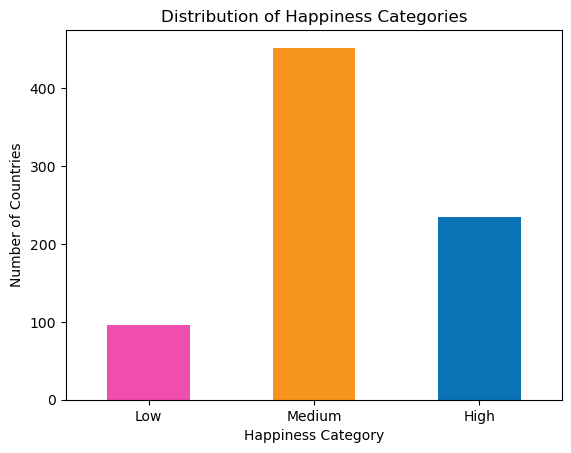

In [149]:
import matplotlib.pyplot as plt

order = ["Low", "Medium", "High"]

df["Happiness_Category"].value_counts().reindex(order).plot(
    kind="bar",
    color=[
        "#F04EAE",   # Pink
        "#F7941D",   # Orange
        "#0B73B6"    # Blue
    ]
)

plt.title("Distribution of Happiness Categories")
plt.xlabel("Happiness Category")
plt.ylabel("Number of Countries")
plt.xticks(rotation=0)

plt.show()

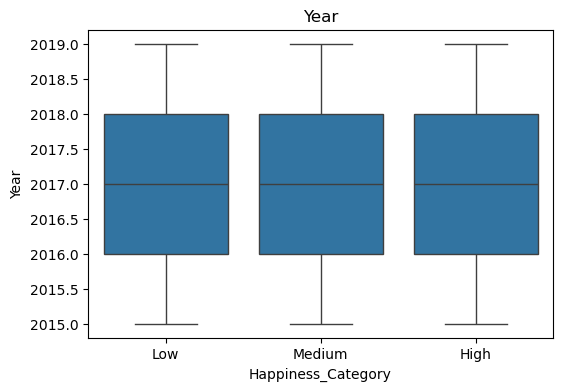

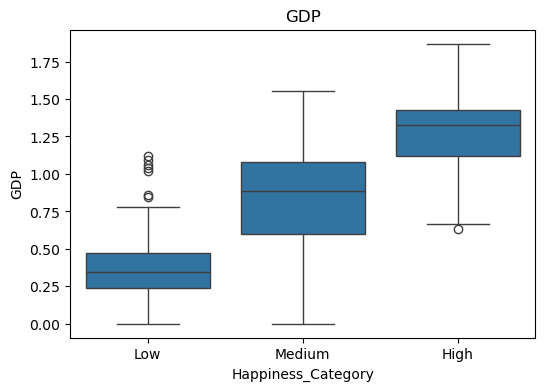

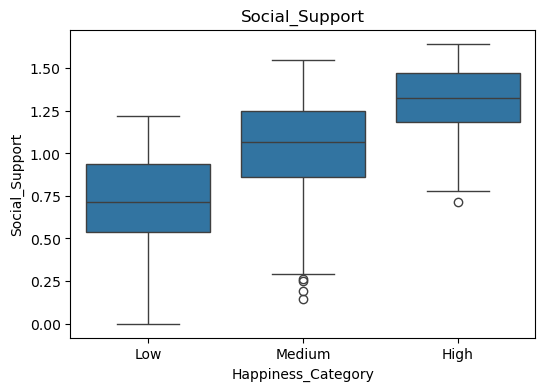

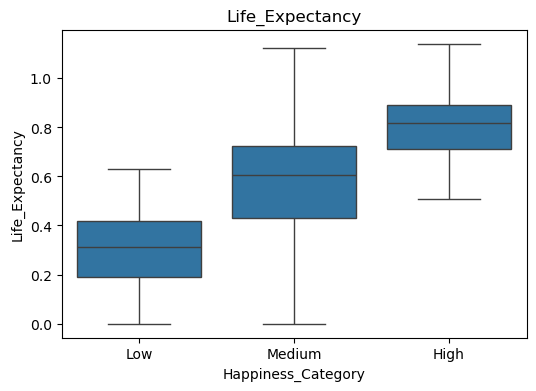

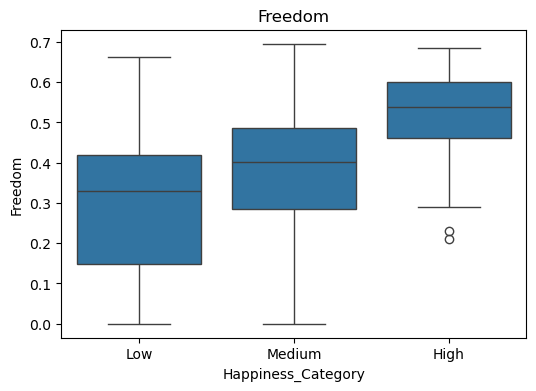

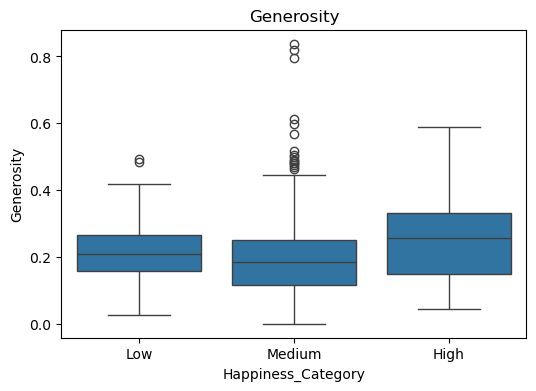

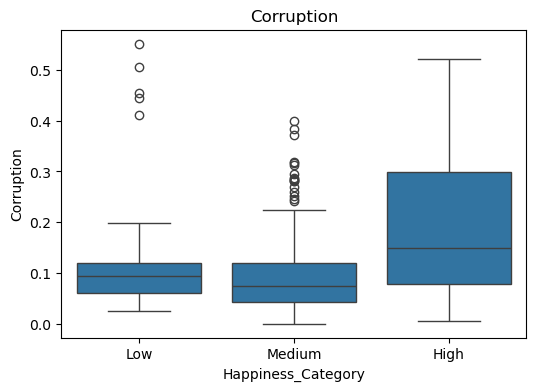

In [42]:
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=train_df,
        x="Happiness_Category",
        y=col
    )
    plt.title(col)
    plt.show()

### 5. Feature Engineering

In [43]:
#separating numerical and categorical features
categorical_cols = ["Country"]
numerical_cols = ["Year", "GDP", "Social_Support", "Life_Expectancy", "Freedom", "Generosity", "Corruption"]

In [44]:
#encoding the categorical variable
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [45]:
#scaling the numerical variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])

In [46]:
#converting encoded features (categorical) back to dataframe
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(categorical_cols),
                               index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(categorical_cols),
                               index=X_test.index)

In [47]:
#converting scaled features (numerical) back to dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numerical_cols,
                               index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numerical_cols,
                               index=X_test.index)

In [48]:
#concatenating the features
X_train_final = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test_encoded], axis=1)

In [49]:
print(X_train_final.shape)
print(X_test_final.shape)

X_train_final.head()

(624, 173)
(157, 173)


,Year,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption,Country_Afghanistan,Country_Albania,Country_Algeria,...,Country_United Arab Emirates,Country_United Kingdom,Country_United States,Country_Uruguay,Country_Uzbekistan,Country_Venezuela,Country_Vietnam,Country_Yemen,Country_Zambia,Country_Zimbabwe
482,0.704002,0.248682,1.169356,0.854833,1.430245,-0.613877,-0.206530,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
683,1.409135,1.038056,1.045148,1.945999,0.208597,-1.208904,0.159506,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
539,0.704002,0.186429,0.830889,-0.208148,0.541774,-0.830982,0.234591,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
115,-1.411395,-2.089060,-0.909020,-1.057687,-0.834638,0.195199,-0.569564,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
481,0.704002,1.072918,1.309091,1.152790,1.332252,0.182173,0.947893,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 5.1 Feature Selection

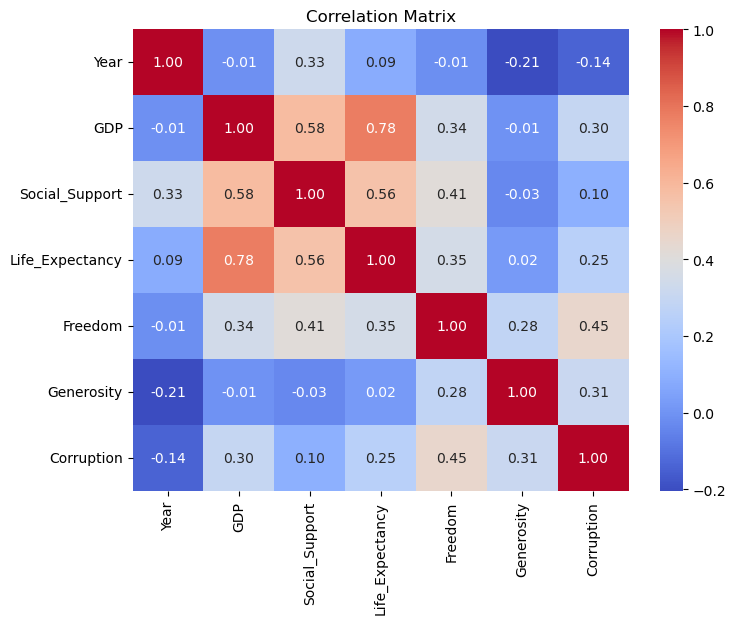

In [50]:
#correlation matrix between numerical variables
corr_matrix = X_train_scaled.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Feature Selection: To identify potential multicollinearity, a correlation matrix was computed for the numerical features. A threshold of |0.80| was used to identify highly correlated variables. The highest observed correlation was 0.78 between GDP and Life_Expectancy, which is below the chosen threshold. Despite GDP and Life Expectancy being strongly correlated, they measure different aspects of a country's well-being. Therefore, no features were removed, and all predictors were retained for model training.

### 6. Model Building

#### 6.1 Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000)

In [53]:
log_model.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [54]:
log_pred = log_model.predict(X_test_final)

Train Accuracy: 0.9198717948717948
Test Accuracy: 0.8535031847133758

Classification Report:
              precision    recall  f1-score   support

        High       0.91      0.85      0.88        47
      Medium       0.85      0.91      0.88        91
         Low       0.73      0.58      0.65        19

    accuracy                           0.85       157
   macro avg       0.83      0.78      0.80       157
weighted avg       0.85      0.85      0.85       157



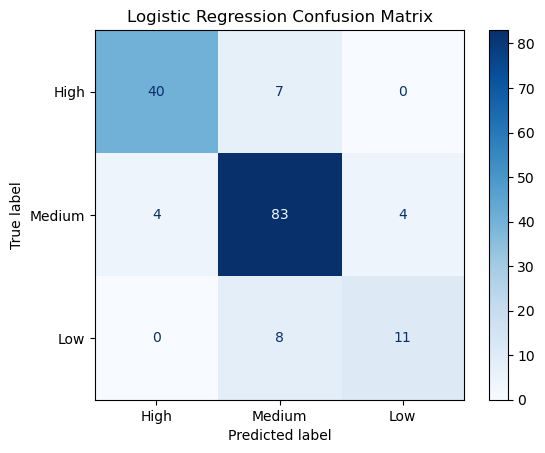

In [106]:
#model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Accuracy
print("Train Accuracy:", log_model.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, log_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, log_pred, labels=["High", "Medium", "Low"]))

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    log_pred,         
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Interpretation:

High happiness category:
- 40 were correctly classified.
- 7 were incorrectly classified as Medium.
- 0 misclassified as Low.

Medium happiness category:
- 83 were correctly identified.
- 4 classified as High.
- 4 classified as Low.

Low happiness category:
- 11 were correctly classified.
- 0 countries incorrectly classified as High.
- 8 classified as Medium.

Logistic Regression achieved a test accuracy of 85.35%, demonstrating good predictive performance despite the class imbalance introduced by the new target definition. The model performs particularly well in identifying High and Medium happiness categories, both achieving an F1-score of 0.88.
Performance is weaker for the Low happiness category, with a recall of 58%, indicating that some low-happiness countries are incorrectly assigned to higher happiness levels. This is expected because the Low class represents only 12% of the dataset.

#### 6.2 K-Nearest Neighbors (KNN)

In [70]:
from sklearn.neighbors import KNeighborsClassifier

In [71]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [72]:
knn_model.fit(X_train_final, y_train)

KNeighborsClassifier()

In [73]:
knn_pred = knn_model.predict(X_test_final)

Train Accuracy: 0.9166666666666666
Test Accuracy: 0.8280254777070064

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.79      0.80        47
      Medium       0.85      0.86      0.85        91
         Low       0.79      0.79      0.79        19

    accuracy                           0.83       157
   macro avg       0.81      0.81      0.81       157
weighted avg       0.83      0.83      0.83       157



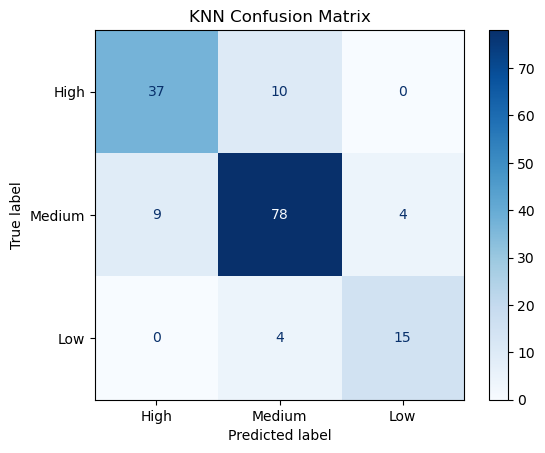

In [107]:
#model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Accuracy
print("Train Accuracy:", knn_model.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, knn_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, knn_pred, labels=["High", "Medium", "Low"]))

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    knn_pred,         
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot(cmap="Blues")

plt.title("KNN Confusion Matrix")
plt.show()

Interpretation:

High happiness category:
- 37 were correctly classified.
- 10 were incorrectly classified as Medium.
- 0 misclassified as Low.

Medium happiness category:
- 78 were correctly identified.
- 9 classified as High.
- 4 classified as Low.

Low happiness category:
- 15 were correctly classified.
- 0 countries incorrectly classified as High.
- 4 classified as Medium.

KNN achieved a test accuracy of 82.8%, slightly lower than Logistic Regression (85.4%). However, it provides a more balanced performance across the three happiness categories.

KNN substantially improves the prediction of the minority Low class, increasing its recall from 58% (Logistic Regression) to 79%. This indicates that KNN is considerably better at identifying countries with low happiness scores.

#### 6.3 Decision Tree

In [76]:
from sklearn.tree import DecisionTreeClassifier

In [77]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [78]:
dt_model.fit(X_train_final, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [79]:
dt_pred = dt_model.predict(X_test_final)

Train Accuracy: 0.8301282051282052
Test Accuracy: 0.821656050955414

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.89      0.83        47
      Medium       0.83      0.87      0.85        91
         Low       1.00      0.42      0.59        19

    accuracy                           0.82       157
   macro avg       0.87      0.73      0.76       157
weighted avg       0.84      0.82      0.81       157



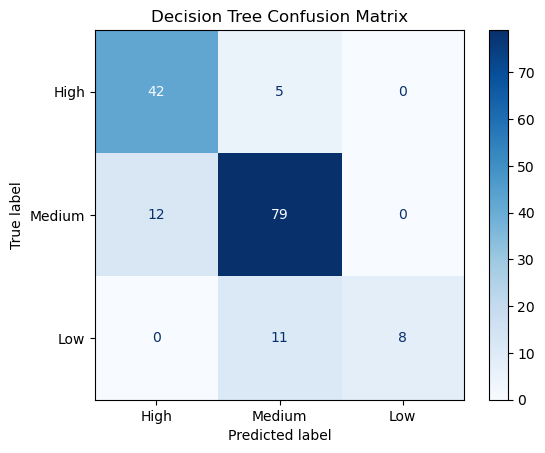

In [108]:
#model evaluation

# Accuracy
print("Train Accuracy:", dt_model.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, dt_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, labels=["High", "Medium", "Low"]))

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    dt_pred,         
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()

Interpretation:

High happiness category:
- 42 were correctly classified.
- 5 were incorrectly classified as Medium.
- 0 misclassified as Low.

Medium happiness category:
- 79 were correctly identified.
- 12 classified as High.
- 0 classified as Low.

Low happiness category:
- 8 were correctly classified.
- 0 countries incorrectly classified as High.
- 11 classified as Medium.

The Decision Tree achieved a test accuracy of 82.2%. Its greatest strength is the absence of overfitting, as shown by the nearly identical training and testing accuracies.

However, the model performs poorly on the minority Low class. Although every country predicted as Low is actually Low (precision = 1.00), the model only identifies 42% of all Low-happiness countries. This indicates that the Decision Tree is very conservative when assigning observations to the Low category, preferring to classify uncertain cases as Medium instead.

Overall, while the Decision Tree provides stable predictions and generalizes well, its limited ability to detect the minority class makes it less suitable for this classification.

#### 6.4 Bagging

In [81]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [82]:
DecisionTreeClassifier(max_depth=20)

DecisionTreeClassifier(max_depth=20)

In [83]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=20),
    n_estimators=100,
    random_state=42
)

In [84]:
bagging_model.fit(X_train_final, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=20),
                  n_estimators=100, random_state=42)

In [85]:
bagging_pred = bagging_model.predict(X_test_final)

Train Accuracy: 0.9983974358974359
Test Accuracy: 0.8789808917197452

Classification Report:
              precision    recall  f1-score   support

        High       0.89      0.85      0.87        47
      Medium       0.88      0.92      0.90        91
         Low       0.88      0.74      0.80        19

    accuracy                           0.88       157
   macro avg       0.88      0.84      0.86       157
weighted avg       0.88      0.88      0.88       157



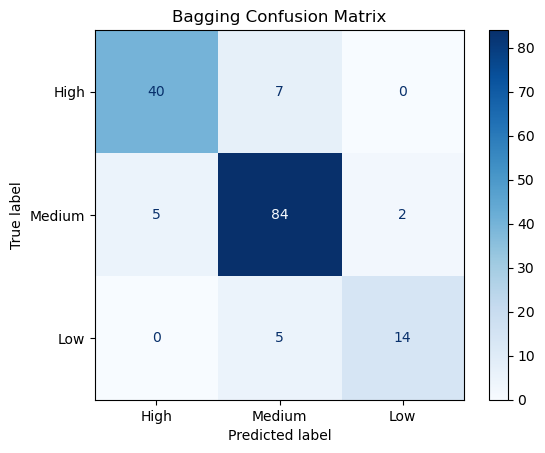

In [150]:
#model evaluation

# Accuracy
print("Train Accuracy:", bagging_model.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, bagging_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, bagging_pred, labels=["High", "Medium", "Low"]))

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    bagging_pred,         
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot(cmap="Blues")

plt.title("Bagging Confusion Matrix")
plt.show()

Interpretation:

High happiness category:
- 40 were correctly classified.
- 7 were incorrectly classified as Medium.
- 0 misclassified as Low.

Medium happiness category:
- 84 were correctly identified.
- 5 classified as High.
- 2 classified as Low.

Low happiness category:
- 14 were correctly classified.
- 0 countries incorrectly classified as High.
- 5 classified as Medium.

The Bagging Classifier achieved the highest overall test accuracy (87.9%) and the strongest F1-scores across the evaluated models. It performs consistently well for all three happiness categories, particularly the Medium class, while also providing strong performance for the minority Low class. However, the model exhibits signs of overfitting, as indicated by the very high training accuracy (99.8%).

#### 6.5 Random Forest

In [87]:
from sklearn.ensemble import RandomForestClassifier

In [88]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

In [89]:
rf_model.fit(X_train_final, y_train)

RandomForestClassifier(max_depth=20, random_state=42)

In [90]:
rf_pred = rf_model.predict(X_test_final)

Train Accuracy: 0.9919871794871795
Test Accuracy: 0.8662420382165605

Classification Report:
              precision    recall  f1-score   support

        High       0.88      0.81      0.84        47
      Medium       0.86      0.92      0.89        91
         Low       0.88      0.74      0.80        19

    accuracy                           0.87       157
   macro avg       0.87      0.82      0.84       157
weighted avg       0.87      0.87      0.86       157



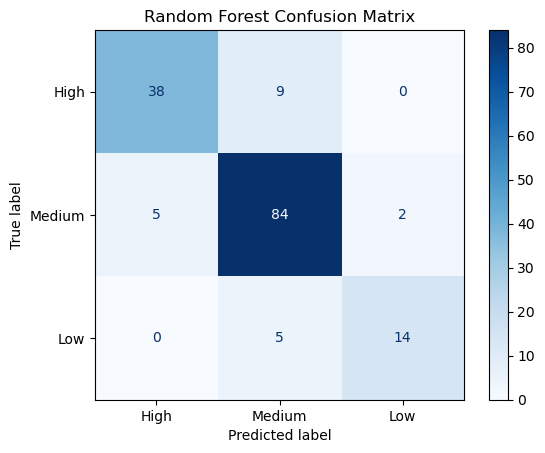

In [110]:
#model evaluation

# Accuracy
print("Train Accuracy:", rf_model.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, rf_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, labels=["High", "Medium", "Low"]))

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    rf_pred,         
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

In [92]:
#importance ranking of the features
feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(7)

,Feature,Importance
1,GDP,0.164569
3,Life_Expectancy,0.125407
4,Freedom,0.115082
2,Social_Support,0.105702
6,Corruption,0.096562
5,Generosity,0.059069
0,Year,0.021590


Interpretation:

High happiness category:
- 38 were correctly classified.
- 9 were incorrectly classified as Medium.
- 0 misclassified as Low.

Medium happiness category:
- 84 were correctly identified.
- 5 classified as High.
- 2 classified as Low.

Low happiness category:
- 14 were correctly classified.
- 0 countries incorrectly classified as High.
- 5 classified as Medium.

The Random Forest classifier achieved 86.62% test accuracy, which is a similar result to the Bagging Model. It performs consistently across all three happiness categories and predicts the minority Low class substantially better than Logistic Regression and Decision Tree. Although the model exhibits some overfitting, its predictive performance remains high. Compared with Bagging, Random Forest produces nearly identical results but with slightly lower overall accuracy and a small reduction in performance for the High happiness category.

The feature importance analysis suggests that GDP is the strongest predictor of a country's happiness category, followed by Life Expectancy, Freedom, and Social Support. These findings are consistent with the World Happiness Report, where economic prosperity, health, and social well-being are among the most influential determinants of life satisfaction.

#### 6.6 Gradient Boosting

In [93]:
from sklearn.ensemble import GradientBoostingClassifier

In [94]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [95]:
gb_model.fit(X_train_final, y_train)

GradientBoostingClassifier(random_state=42)

In [96]:
gb_pred = gb_model.predict(X_test_final)

Train Accuracy: 0.9823717948717948
Test Accuracy: 0.8853503184713376

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.85      0.90        47
      Medium       0.87      0.95      0.91        91
         Low       0.81      0.68      0.74        19

    accuracy                           0.89       157
   macro avg       0.88      0.83      0.85       157
weighted avg       0.89      0.89      0.88       157



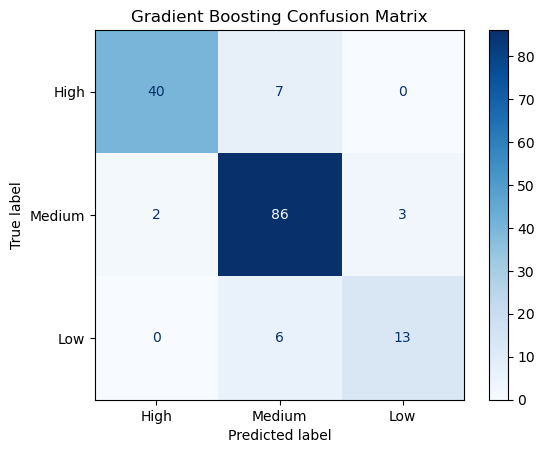

In [111]:
#model evaluation

# Accuracy
print("Train Accuracy:", gb_model.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, gb_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, gb_pred, labels=["High", "Medium", "Low"]))

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    gb_pred,         
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot(cmap="Blues")

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [153]:
#importance ranking of the features
gb_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

gb_importance.head(5)

,Feature,Importance
0,GDP,0.397322
1,Freedom,0.121743
2,Life_Expectancy,0.077794
3,Social_Support,0.059601
4,Corruption,0.035032


Interpretation:

High happiness category:
- 40 were correctly classified.
- 7 were incorrectly classified as Medium.
- 0 misclassified as Low.

Medium happiness category:
- 86 were correctly identified.
- 2 classified as High.
- 3 classified as Low.

Low happiness category:
- 13 were correctly classified.
- 0 countries incorrectly classified as High.
- 6 classified as Medium.

Gradient Boosting achieved the best overall performance among all evaluated models, with the highest test accuracy (88.54%) and excellent F1-scores for the High and Medium happiness categories. Although the model exhibits some overfitting, it generalizes better than Bagging and Random Forest while maintaining superior predictive accuracy.

The model also performs well on the minority Low class, achieving an F1-score of 0.74. While KNN remains the strongest model for identifying Low-happiness countries specifically, Gradient Boosting offers the best balance between overall accuracy and class-level performance.

GDP is by far the most influential predictor, accounting for nearly 40% of the model's total importance. This suggests that economic prosperity plays the largest role in distinguishing between happiness categories in the dataset.

#### 6.7 Adaptive Boosting

In [99]:
from sklearn.ensemble import AdaBoostClassifier

In [100]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

In [101]:
ada_model.fit(X_train_final, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [102]:
ada_pred = ada_model.predict(X_test_final)

Train Accuracy: 0.7692307692307693
Test Accuracy: 0.7707006369426752

Classification Report:
              precision    recall  f1-score   support

        High       0.79      0.70      0.74        47
      Medium       0.79      0.82      0.81        91
         Low       0.65      0.68      0.67        19

    accuracy                           0.77       157
   macro avg       0.74      0.74      0.74       157
weighted avg       0.77      0.77      0.77       157



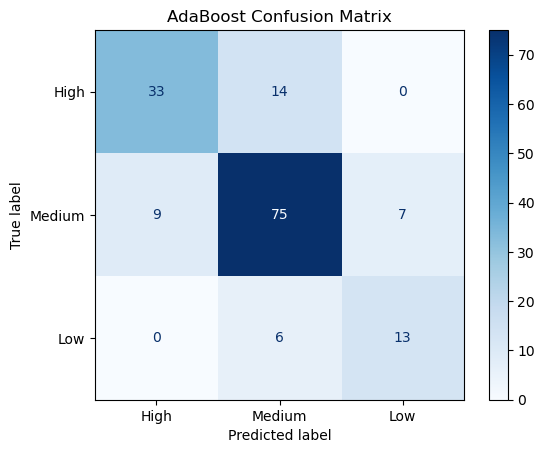

In [112]:
#model evaluation

# Accuracy
print("Train Accuracy:", ada_model.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, ada_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, ada_pred, labels=["High", "Medium", "Low"]))

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    ada_pred,         
    labels=["High", "Medium", "Low"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Medium", "Low"]
)

disp.plot(cmap="Blues")

plt.title("AdaBoost Confusion Matrix")
plt.show()

Interpretation:

High happiness category:
- 33 were correctly classified.
- 14 were incorrectly classified as Medium.
- 0 misclassified as Low.

Medium happiness category:
- 75 were correctly identified.
- 9 classified as High.
- 7 classified as Low.

Low happiness category:
- 13 were correctly classified.
- 0 countries incorrectly classified as High.
- 6 classified as Medium.

AdaBoost achieved the lowest test accuracy (77.1%) among all evaluated models. Unlike Bagging and Random Forest, it shows virtually no overfitting, as evidenced by the nearly identical training and testing accuracies. However, this stability comes at the cost of lower predictive performance, indicating that the model is likely underfitting the data.

Overall conclusion:

- Seven classification models were evaluated to predict countries' happiness categories. Among all the models tested, Gradient Boosting would be the recommended model. It achieved the highest test accuracy (88.54%), the highest weighted F1-score (tied with Bagging), and consistently strong performance across all three happiness categories. Although it shows some overfitting, the gap between training and testing accuracy is smaller than for Bagging and Random Forest, making it the best compromise between predictive performance and generalization.

In [105]:
print(y_test.value_counts())
print(gb_model.classes_)

Happiness_Category
Medium    91
High      47
Low       19
Name: count, dtype: int64
['High' 'Low' 'Medium']


### 7. Best Model Evaluation

In [117]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Bagging",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost"
    ],
    "Train Accuracy": [
        0.9199,
        0.9167,
        0.8301,
        0.9984,
        0.9920,
        0.9824,
        0.7692
    ],
    "Test Accuracy": [
        0.8535,
        0.8280,
        0.8217,
        0.8790,
        0.8662,
        0.8854,
        0.7707
    ],
    "Avg F1-score": [
        0.80,
        0.81,
        0.76,
        0.86,
        0.84,
        0.85,
        0.74
    ],
    "Weighted F1": [
        0.85,
        0.83,
        0.81,
        0.88,
        0.86,
        0.88,
        0.77
    ]
})

results = results.sort_values(by="Test Accuracy", ascending=False)

results.style.hide(axis="index") \
    .format({
        "Train Accuracy": "{:.2%}",
        "Test Accuracy": "{:.2%}",
        "Avg F1-score": "{:.3f}",
        "Weighted F1": "{:.3f}"
    }) \
    .highlight_max(
        subset=["Train Accuracy", "Test Accuracy", "Avg F1-score", "Weighted F1"],
        color="lightblue"
    )

Model,Train Accuracy,Test Accuracy,Avg F1-score,Weighted F1
Gradient Boosting,98.24%,88.54%,0.850,0.880
Bagging,99.84%,87.90%,0.860,0.880
Random Forest,99.20%,86.62%,0.840,0.860
Logistic Regression,91.99%,85.35%,0.800,0.850
KNN,91.67%,82.80%,0.810,0.830
Decision Tree,83.01%,82.17%,0.760,0.810
AdaBoost,76.92%,77.07%,0.740,0.770


- After comparing the seven classification models using train accuracy, test accuracy, average F1-score, and weighted F1. Gradient Boosting achieved the highest test accuracy (88.54%), making it the best overall model for predicting happiness categories. Bagging performed almost as well and obtained the highest average F1-score (0.860), indicating a slightly better balance across all three classes. Random Forest also showed strong performance but was slightly behind the top two models. Logistic Regression provided a solid baseline, while KNN and Decision Tree achieved moderate performance. AdaBoost had the lowest scores across all metrics, suggesting it was the least suitable model for this dataset. Overall, Gradient Boosting was selected as the final model because it offered the best combination of predictive accuracy and balanced performance across the different happiness categories.

### 8. Hyperparameter Tuning

#### 8.1 GridSearch (Gradient Boosting)

In [118]:
from sklearn.model_selection import GridSearchCV

In [119]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

In [120]:
grid_search_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [121]:
grid_search_gb.fit(X_train_final, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [50, 100, 200]},
             scoring='f1_macro', verbose=1)

Exception ignored in: <function ResourceTracker.__del__ at 0x10ede6ca0>
Traceback (most recent call last):
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1094e6ca0>
Traceback (most recent call last):
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1

In [122]:
print("Best parameters:")
print(grid_search_gb.best_params_)

print("\nBest cross-validation Avg F1-score:")
print(grid_search_gb.best_score_)

Best parameters:
{'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 200}

Best cross-validation Avg F1-score:
0.8505140760518858


In [123]:
best_gb = grid_search_gb.best_estimator_

Train Accuracy: 0.9967948717948718
Test Accuracy: 0.8980891719745223
              precision    recall  f1-score   support

        High       0.98      0.87      0.92        47
         Low       0.81      0.68      0.74        19
      Medium       0.88      0.96      0.92        91

    accuracy                           0.90       157
   macro avg       0.89      0.84      0.86       157
weighted avg       0.90      0.90      0.90       157



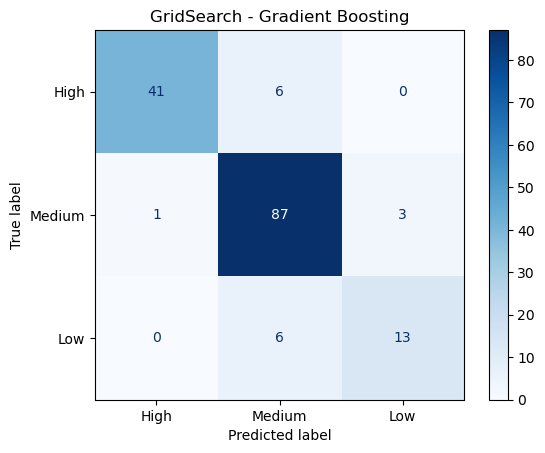

In [136]:
gb_tuned_pred = best_gb.predict(X_test_final)

from sklearn.metrics import accuracy_score, classification_report

print("Train Accuracy:", best_gb.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, gb_tuned_pred))

print(classification_report(y_test, gb_tuned_pred))

class_order = ["High", "Medium", "Low"]

cm = confusion_matrix(
    y_test,
    gb_tuned_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_order
)

disp.plot(cmap="Blues")
plt.title("GridSearch - Gradient Boosting")
plt.show()

The hyperparameter tuning improved the model across all evaluation metrics.

Test Accuracy increased from 88.54% to 89.81%, showing better performance on unseen data.
Avg F1-score increased from 0.850 to 0.860, indicating a more balanced performance across the High, Medium, and Low happiness categories.
Weighted F1 improved from 0.880 to 0.900, reflecting stronger overall classification performance while accounting for the class imbalance.

#### 8.2 Randomized Search (Gradient Boosting)

In [127]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [128]:
param_dist = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [129]:
random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,          
    scoring="f1_macro",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [130]:
random_search.fit(X_train_final, y_train)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


RandomizedSearchCV(cv=2, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [131]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation Avg F1-score:")
print(random_search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.3}

Best cross-validation Avg F1-score:
0.8324539517096643


Train Accuracy: 0.9983974358974359
Test Accuracy: 0.8980891719745223
              precision    recall  f1-score   support

        High       0.98      0.87      0.92        47
         Low       0.81      0.68      0.74        19
      Medium       0.88      0.96      0.92        91

    accuracy                           0.90       157
   macro avg       0.89      0.84      0.86       157
weighted avg       0.90      0.90      0.90       157



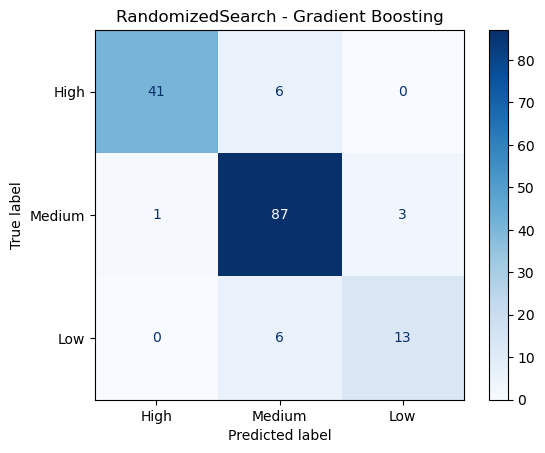

In [134]:
best_random_gb = random_search.best_estimator_

random_pred = best_random_gb.predict(X_test_final)

from sklearn.metrics import accuracy_score, classification_report

print("Train Accuracy:", best_random_gb.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, random_pred))

print(classification_report(y_test, random_pred))

class_order = ["High", "Medium", "Low"]

cm = confusion_matrix(
    y_test,
    random_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_order
)

disp.plot(cmap="Blues")
plt.title("RandomizedSearch - Gradient Boosting")
plt.show()

Hyperparameter tuning was performed using both GridSearchCV and RandomizedSearchCV. GridSearchCV identified the optimal parameter combination by evaluating all combinations in the predefined grid, while RandomizedSearchCV evaluated only a random subset of parameter combinations. Despite using only five iterations and two-fold cross-validation to reduce computational time, RandomizedSearchCV achieved the same predictive performance as GridSearchCV on the test set. This suggests that the optimal parameter configuration was relatively easy to identify and confirms the robustness of the Gradient Boosting model.

#### 8.3 GridSearch (Bagging)

In [135]:
from sklearn.ensemble import BaggingClassifier

In [137]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0]
}

In [138]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

In [139]:
grid_search_bag = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [140]:
grid_search_bag.fit(X_train_final, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                         random_state=42),
             n_jobs=-1,
             param_grid={'max_features': [0.5, 0.7, 1.0],
                         'max_samples': [0.5, 0.7, 1.0],
                         'n_estimators': [50, 100, 200]},
             scoring='f1_macro', verbose=1)

In [141]:
print(grid_search_bag.best_params_)
print(grid_search_bag.best_score_)

{'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 50}
0.8038431334778912


Train Accuracy: 1.0
Test Accuracy: 0.8662420382165605
              precision    recall  f1-score   support

        High       0.89      0.87      0.88        47
         Low       0.76      0.68      0.72        19
      Medium       0.87      0.90      0.89        91

    accuracy                           0.87       157
   macro avg       0.84      0.82      0.83       157
weighted avg       0.86      0.87      0.87       157



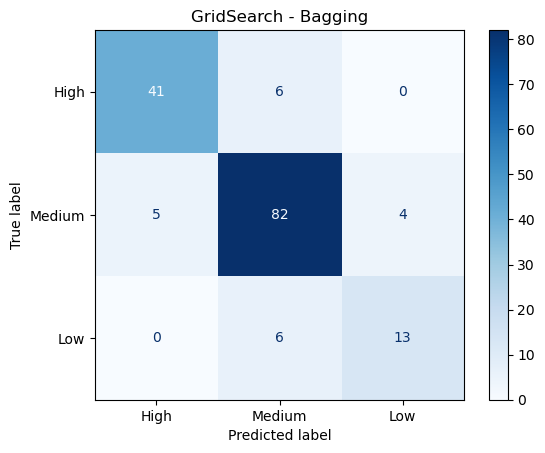

In [142]:
best_bag = grid_search_bag.best_estimator_

bag_pred = best_bag.predict(X_test_final)

print("Train Accuracy:", best_bag.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, bag_pred))
print(classification_report(y_test, bag_pred))

class_order = ["High", "Medium", "Low"]

cm = confusion_matrix(
    y_test,
    bag_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_order
)

disp.plot(cmap="Blues")
plt.title("GridSearch - Bagging")
plt.show()

#### 8.4 RandomizedSearch (Bagging)

In [144]:
param_dist = {
    "n_estimators": [50,100,150,200,250,300],
    "max_samples": [0.4,0.5,0.6,0.7,0.8,1.0],
    "max_features": [0.4,0.5,0.6,0.7,0.8,1.0]}

In [145]:
random_search_bag = RandomizedSearchCV(
    estimator=bagging,
    param_distributions=param_dist,
    n_iter=5,
    scoring="f1_macro",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [146]:
random_search_bag.fit(X_train_final, y_train)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


RandomizedSearchCV(cv=2,
                   estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                               random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_features': [0.4, 0.5, 0.6, 0.7,
                                                         0.8, 1.0],
                                        'max_samples': [0.4, 0.5, 0.6, 0.7, 0.8,
                                                        1.0],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300]},
                   random_state=42, scoring='f1_macro', verbose=1)

Train Accuracy: 1.0
Test Accuracy: 0.8662420382165605
              precision    recall  f1-score   support

        High       0.91      0.85      0.88        47
         Low       0.76      0.68      0.72        19
      Medium       0.86      0.91      0.89        91

    accuracy                           0.87       157
   macro avg       0.85      0.82      0.83       157
weighted avg       0.87      0.87      0.87       157



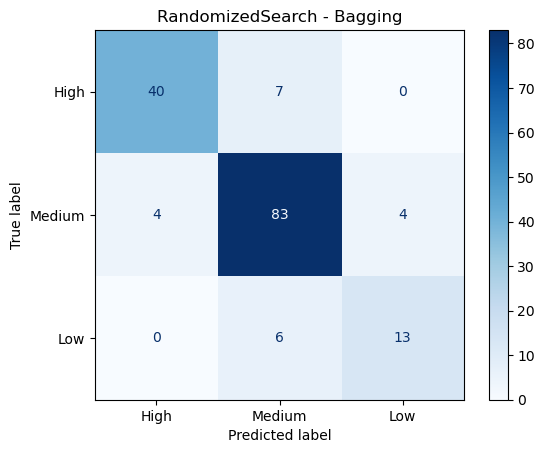

Exception ignored in: <function ResourceTracker.__del__ at 0x104f2aca0>
Traceback (most recent call last):
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106f4aca0>
Traceback (most recent call last):
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/meli/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1

In [147]:
best_random_bag = random_search_bag.best_estimator_

random_bag_pred = best_random_bag.predict(X_test_final)

print("Train Accuracy:", best_random_bag.score(X_train_final, y_train))
print("Test Accuracy:", accuracy_score(y_test, random_bag_pred))
print(classification_report(y_test, random_bag_pred))

cm = confusion_matrix(
    y_test,
    random_bag_pred,
    labels=class_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_order
)

disp.plot(cmap="Blues")
plt.title("RandomizedSearch - Bagging")
plt.show()

I applied both GridSearchCV and RandomizedSearchCV to the two best-performing models. For Gradient Boosting, hyperparameter tuning improved test accuracy and F1-scores, making it our final model. In contrast, tuning Bagging did not improve performance. Although the tuned Bagging model achieved perfect training accuracy, its performance on the test set decreased slightly, indicating mild overfitting. This highlights that hyperparameter tuning does not always lead to better generalization and reinforces the importance of evaluating models on unseen data.

### 9. Conclusions

1. Compared seven classification models.
2. Identified Gradient Boosting and Bagging as the strongest performers.
3. Tuned both using GridSearchCV and RandomizedSearchCV.
4. Found that Gradient Boosting benefited from tuning, while Bagging did not.
5. Selected the tuned Gradient Boosting model as the final model because it achieved the highest test accuracy (89.81%) and the best overall balance across the three happiness categories.